# Lo llaman asteroide peligroso. Pero deja una cola.

**875163 (1998 SH2)** figura en los catálogos como *asteroide potencialmente peligroso* (Potentially Hazardous Asteroid): una roca que cruza la órbita de la Tierra. Solo que su órbita hace algo que ninguna roca hace — se desvía un poquito, año tras año, como si algo la empujara desde adentro.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** *Non-gravitational acceleration indicative of cometary activity of near-Earth object (875163) 1998 SH2*
Farnocchia et al. · *Nature Astronomy* (2026) · DOI: [10.1038/s41550-026-02913-7](https://doi.org/10.1038/s41550-026-02913-7)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-07-10-neo-1998-sh2-cometa/notebook.ipynb)

**Video:** _(próximamente)_


## De qué va esto

Los cometas se delatan de dos formas cuando el Sol los calienta: sueltan una cola de gas y polvo, y esa fuga de gas actúa como un motorcito que perturba su órbita. Los asteroides, en cambio, son rocas mudas: se mueven solo por gravedad.

Pero hay un puñado de objetos que no muestran cola visible y aun así su órbita se desvía. 1998 SH2 es uno de ellos. Para saber de qué lado está — roca o cometa — tenemos dos pistas que sí podemos medir desde la Tierra:

- El **parámetro de Tisserand (T_J)**: un número que resume la forma de la órbita respecto a Júpiter. Por debajo de 3, la órbita es "de cometa"; por encima, "de asteroide".
- La **aceleración no-gravitacional (A₂)**: cuánto se aparta el objeto del empujón puro de la gravedad. Si hay gas escapando, A₂ deja de ser cero.

Veamos dónde cae 1998 SH2 en cada una, contra las poblaciones completas de asteroides y cometas cercanos a la Tierra.


In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
TJ_FRONTERA   = 3.0        # frontera clásica asteroide (>3) / cometa (<3)
TJ_SH2        = 2.9132     # parámetro de Tisserand de 1998 SH2
A2_SH2        = 6.96e-13   # |aceleración no-gravitacional| de 1998 SH2 (au/día²)
FUENTE        = 'Fuente: Farnocchia et al. (2026), Nature Astronomy | Datos: NASA/JPL Small-Body Database'

COLOR_ASTEROIDE  = '#BBBBBB'   # gris: población de rocas
COLOR_COMETA     = '#2563EB'   # azul CaM: población de cometas
COLOR_SH2        = '#DC2626'   # rojo: nuestro protagonista
COLOR_FRONTERA   = '#D97706'   # amber: umbral T_J = 3

import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Estilo CaM (local → fallback GitHub raw)
BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

# Carga de datos
ast = pd.read_csv('datos/neo_asteroides.csv')   # NEOs clasificados asteroide
com = pd.read_csv('datos/neo_cometas.csv')      # NEOs clasificados cometa

print(f'NEOs asteroides: {len(ast):,}')
print(f'NEOs cometas:    {len(com):,}')
print(f'1998 SH2  → T_J = {TJ_SH2}   |A2| = {A2_SH2:.2e} au/día²')


NEOs asteroides: 42,007
NEOs cometas:    208
1998 SH2  → T_J = 2.9132   |A2| = 6.96e-13 au/día²


## Primera pista: la forma de la órbita

Aquí está.

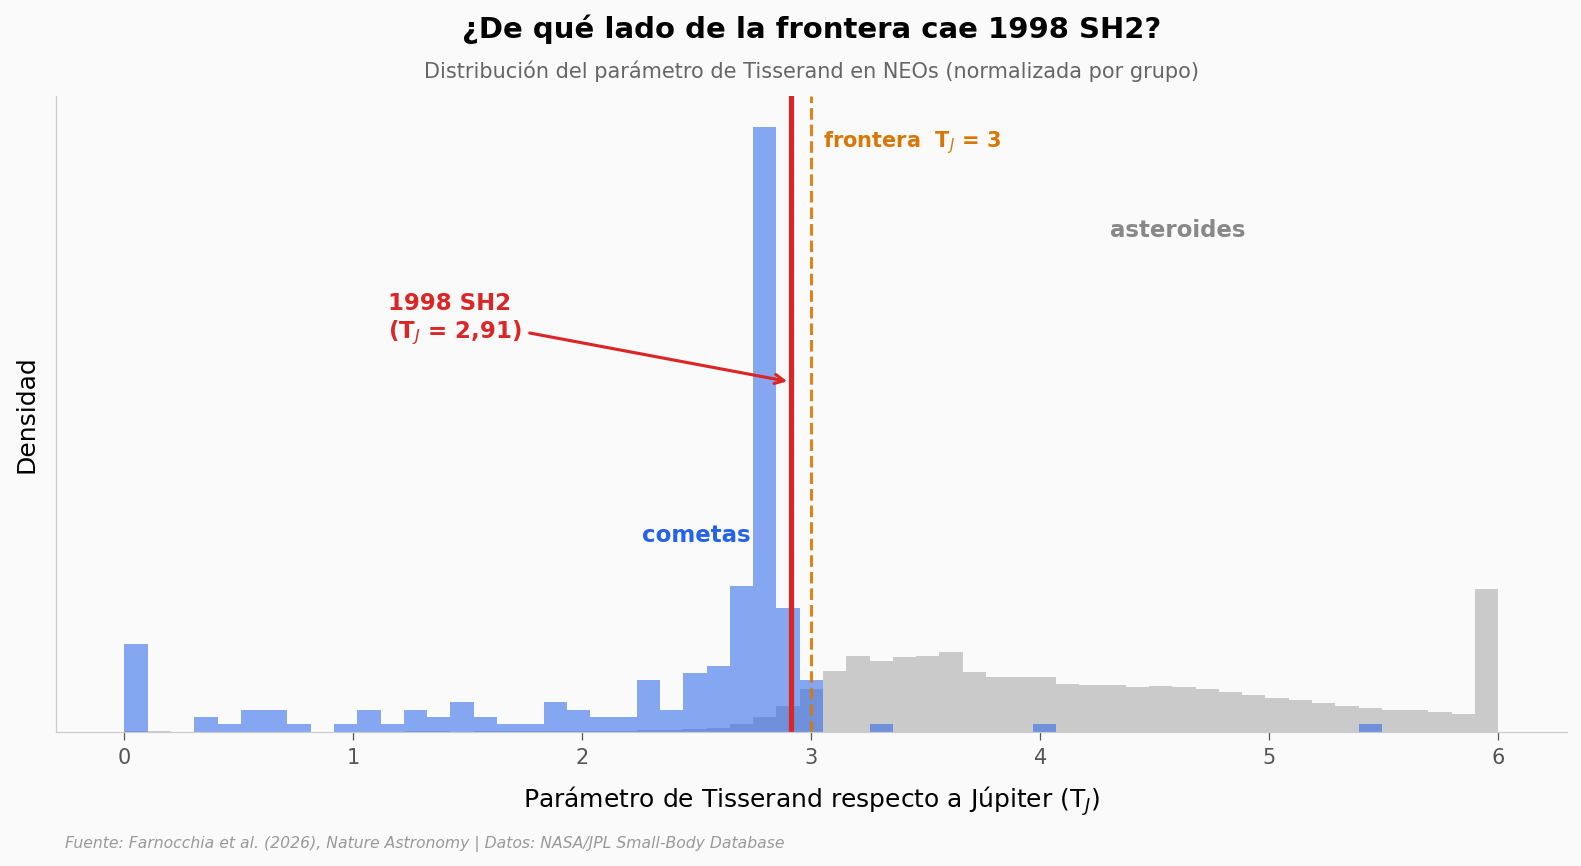

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

bins = np.linspace(0, 6, 60)
ax.hist(ast.tisserand_J.clip(0, 6), bins=bins, density=True,
        color=COLOR_ASTEROIDE, alpha=0.75, label='asteroides')
ax.hist(com.tisserand_J.clip(0, 6), bins=bins, density=True,
        color=COLOR_COMETA, alpha=0.55, label='cometas')

# Frontera T_J = 3
ax.axvline(TJ_FRONTERA, color=COLOR_FRONTERA, linewidth=1.5, linestyle='--', alpha=0.9)
ax.text(TJ_FRONTERA + 0.05, ax.get_ylim()[1]*0.92, 'frontera  T$_J$ = 3',
        color=COLOR_FRONTERA, fontsize=10, fontweight='bold')

# 1998 SH2
ax.axvline(TJ_SH2, color=COLOR_SH2, linewidth=2.5)
ax.annotate('1998 SH2\n(T$_J$ = 2,91)', xy=(TJ_SH2, ax.get_ylim()[1]*0.55),
            xytext=(1.15, ax.get_ylim()[1]*0.62), fontsize=11, fontweight='bold',
            color=COLOR_SH2, arrowprops=dict(arrowstyle='->', color=COLOR_SH2, lw=1.5))

# Inline labels (sin legend box)
ax.text(4.6, ax.get_ylim()[1]*0.78, 'asteroides', color='#888888',
        fontsize=11, fontweight='bold', ha='center')
ax.text(2.5, ax.get_ylim()[1]*0.30, 'cometas', color=COLOR_COMETA,
        fontsize=11, fontweight='bold', ha='center')

ax.set_title('¿De qué lado de la frontera cae 1998 SH2?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Distribución del parámetro de Tisserand en NEOs (normalizada por grupo)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Parámetro de Tisserand respecto a Júpiter (T$_J$)')
ax.set_ylabel('Densidad')
ax.set_yticks([])

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/tisserand_distribucion.png', dpi=200, bbox_inches='tight')
plt.show()


Dos poblaciones, dos montañas separadas. Los cometas se apilan por debajo de 3; los asteroides, por encima. La frontera no es arbitraria: sale de cómo interactúa cada órbita con la gravedad de Júpiter.

Y 1998 SH2, con T_J = 2,91, cae del lado de los cometas. Su órbita ya tiene el pasaporte equivocado para ser una simple roca.


## Segunda pista: el empujón invisible

La forma de la órbita es circunstancial — hay asteroides genuinos que también viven bajo la frontera. La prueba más directa es dinámica: ¿se desvía el objeto de lo que la pura gravedad predice? Esa desviación es A₂, la aceleración no-gravitacional que el JPL ajusta a partir de 27 años de observaciones.


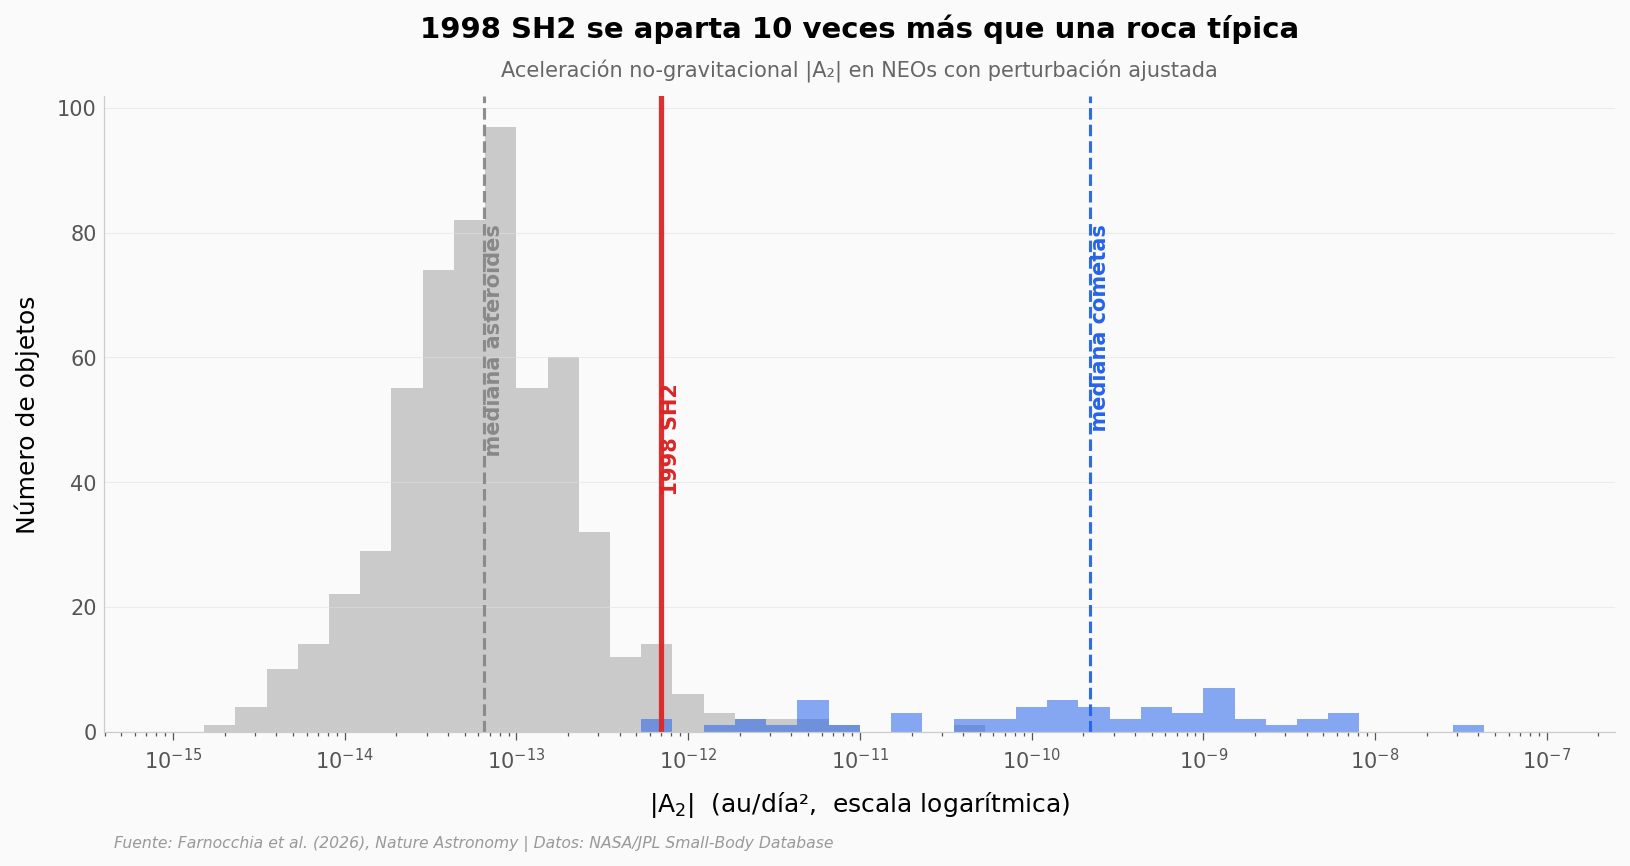

mediana |A2| asteroides: 6.50e-14 au/día²
mediana |A2| cometas:    2.20e-10 au/día²
1998 SH2:  6.96e-13  →  11x la roca típica, 316x más débil que el cometa típico


In [3]:
fig, ax = plt.subplots(figsize=(13, 5.5))

aA2 = ast['A2'].dropna().abs()
cA2 = com['A2'].dropna().abs()

logbins = np.logspace(-15, -7, 45)
ax.hist(aA2, bins=logbins, color=COLOR_ASTEROIDE, alpha=0.75, label='asteroides')
ax.hist(cA2, bins=logbins, color=COLOR_COMETA, alpha=0.55, label='cometas')
ax.set_xscale('log')

med_ast = aA2.median()
med_com = cA2.median()

for val, col, txt, dy in [
    (med_ast, '#888888', 'mediana asteroides', 0.80),
    (med_com, COLOR_COMETA, 'mediana cometas', 0.80),
    (A2_SH2,  COLOR_SH2,  '1998 SH2', 0.55)]:
    lw = 2.5 if col == COLOR_SH2 else 1.5
    ls = '-' if col == COLOR_SH2 else '--'
    ax.axvline(val, color=col, linewidth=lw, linestyle=ls, alpha=0.95)
    ax.text(val, ax.get_ylim()[1]*dy, f'  {txt}', color=col, fontsize=10,
            fontweight='bold', rotation=90, va='top')

ax.set_title('1998 SH2 se aparta 10 veces más que una roca típica',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Aceleración no-gravitacional |A₂| en NEOs con perturbación ajustada',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('|A$_2$|  (au/día²,  escala logarítmica)')
ax.set_ylabel('Número de objetos')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/a2_comparacion.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'mediana |A2| asteroides: {med_ast:.2e} au/día²')
print(f'mediana |A2| cometas:    {med_com:.2e} au/día²')
print(f'1998 SH2:  {A2_SH2:.2e}  →  {A2_SH2/med_ast:.0f}x la roca típica, '
      f'{med_com/A2_SH2:.0f}x más débil que el cometa típico')


## Un cometa débil, no un cometa cualquiera

1998 SH2 no grita "cometa". Su empujón queda en tierra de nadie: unas 10 veces por encima de lo que sacude a una roca normal (el efecto Yarkovsky, calor solar reemitido), pero cientos de veces por debajo del cometa promedio. Es una fuga de gas tan tenue que pasó desapercibida durante décadas.

Aquí conviene ser honestos con lo que muestran los datos y lo que no. Nuestro dato reproducible es el A₂ que el JPL ajustó a la órbita — una perturbación *consistente con* una fuga de gas (outgassing). Que sea gas y no otra cosa lo probaron los autores con telescopios de gran apertura que captaron una cola tenue: eso no lo reproduce este notebook. Lo que sí podemos ver es dónde caen las dos pistas dinámicas a la vez.


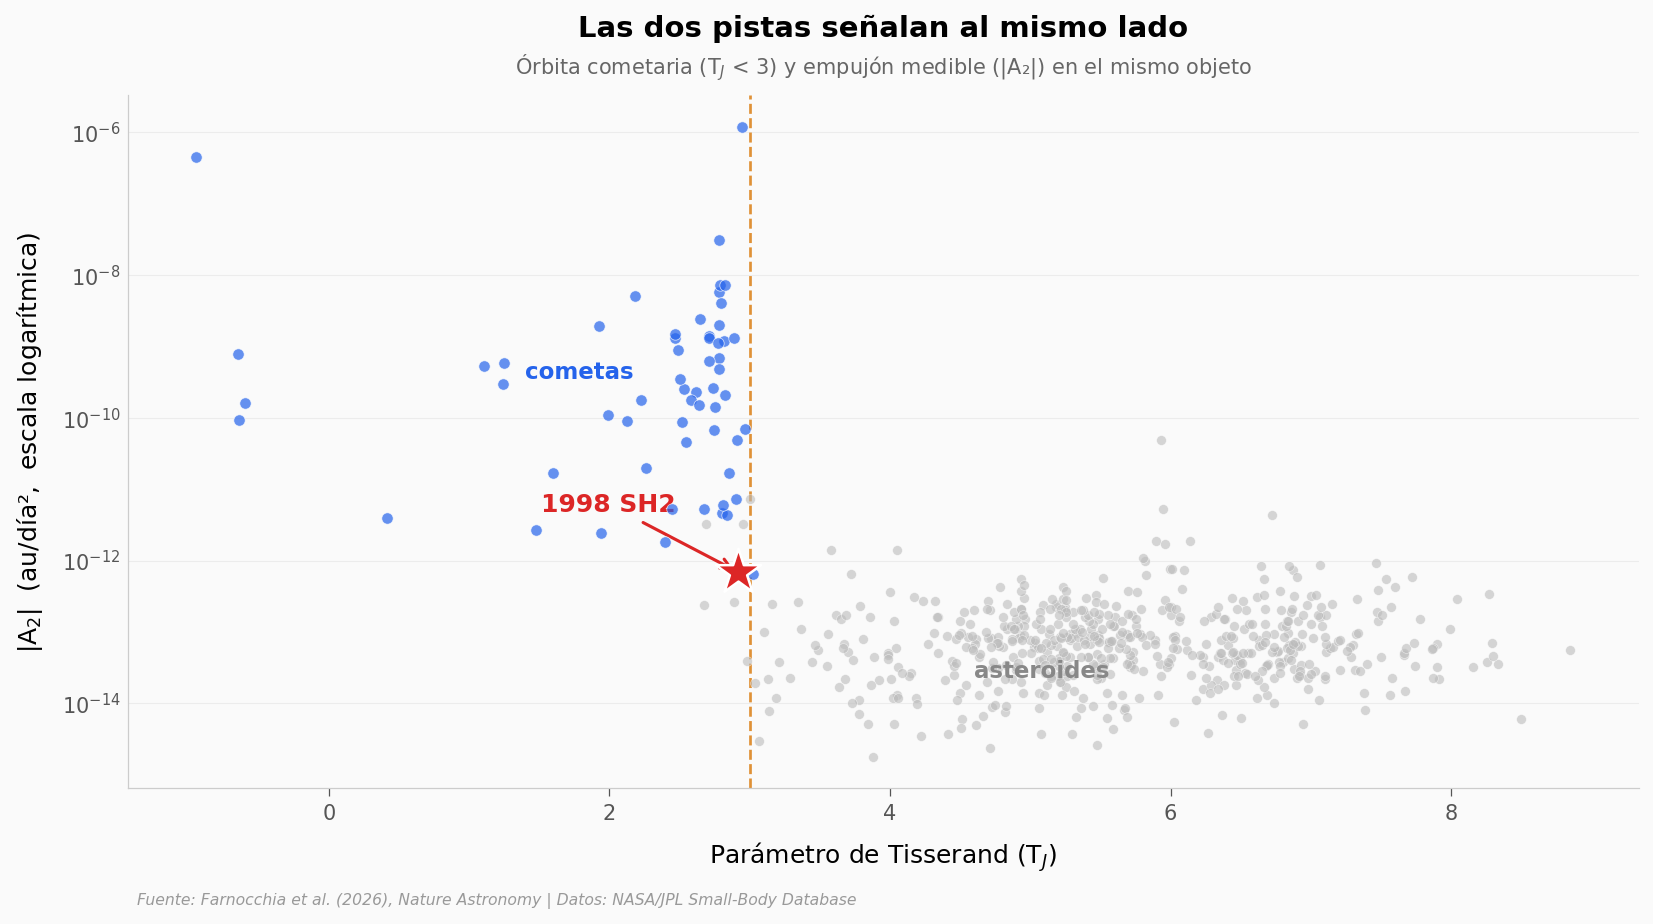

In [4]:
fig, ax = plt.subplots(figsize=(13, 6))

a = ast.dropna(subset=['A2'])
c = com.dropna(subset=['A2'])

ax.scatter(a.tisserand_J, a['A2'].abs(), color=COLOR_ASTEROIDE, s=22, alpha=0.6,
           edgecolors='white', linewidths=0.3, zorder=3)
ax.scatter(c.tisserand_J, c['A2'].abs(), color=COLOR_COMETA, s=30, alpha=0.7,
           edgecolors='white', linewidths=0.4, zorder=4)
ax.scatter([TJ_SH2], [A2_SH2], marker='*', color=COLOR_SH2, s=520,
           edgecolors='white', linewidths=1.2, zorder=6)
ax.annotate('1998 SH2', xy=(TJ_SH2, A2_SH2), xytext=(TJ_SH2 - 1.4, A2_SH2*7),
            fontsize=12, fontweight='bold', color=COLOR_SH2,
            arrowprops=dict(arrowstyle='->', color=COLOR_SH2, lw=1.5))

ax.axvline(TJ_FRONTERA, color=COLOR_FRONTERA, linewidth=1.3, linestyle='--', alpha=0.8)
ax.set_yscale('log')

ax.text(4.6, a['A2'].abs().median()*0.35, 'asteroides', color='#888888',
        fontsize=11, fontweight='bold')
ax.text(1.4, c['A2'].abs().median()*1.6, 'cometas', color=COLOR_COMETA,
        fontsize=11, fontweight='bold')

ax.set_title('Las dos pistas señalan al mismo lado',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Órbita cometaria (T$_J$ < 3) y empujón medible (|A₂|) en el mismo objeto',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Parámetro de Tisserand (T$_J$)')
ax.set_ylabel('|A$_2$|  (au/día²,  escala logarítmica)')

fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/tj_vs_a2.png', dpi=200, bbox_inches='tight')
plt.show()


## ¿Cuántos "asteroides" son cometas escondidos?

Si 1998 SH2 se disfrazó de roca durante 27 años, la pregunta incómoda es cuántos más hay. La órbita da un primer filtro barato: ¿cuántos de los objetos catalogados como asteroides tienen, en realidad, una órbita de cometa?


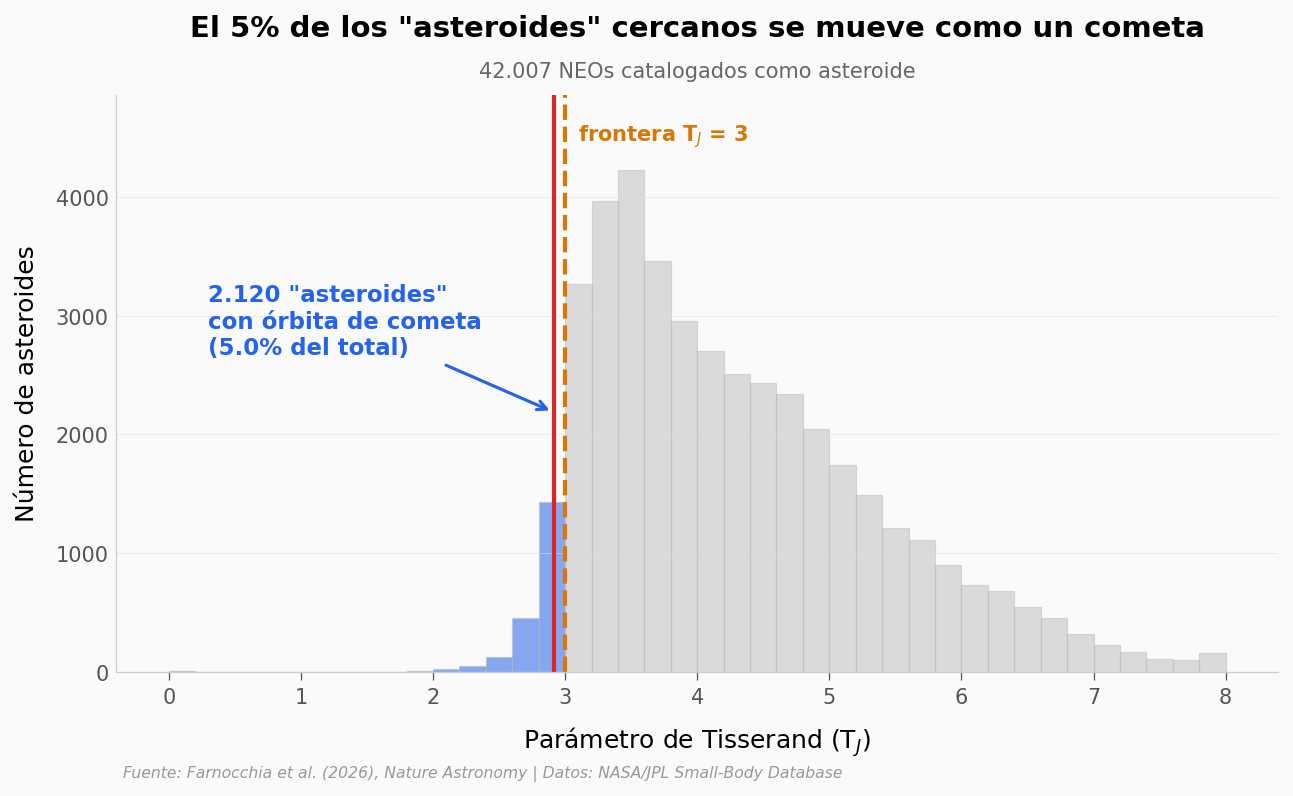

2,120 de 42,007 NEOs asteroides tienen T_J < 3  (5.05%)


In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

data = ast.tisserand_J.clip(0, 8)
n, bins, patches = ax.hist(data, bins=40, color=COLOR_ASTEROIDE, alpha=0.5,
                           edgecolor=COLOR_ASTEROIDE, linewidth=0.6)

# Colorear de azul las barras por debajo de la frontera
for patch, left in zip(patches, bins[:-1]):
    if left < TJ_FRONTERA:
        patch.set_facecolor(COLOR_COMETA)
        patch.set_alpha(0.55)

n_bajo = int((ast.tisserand_J < TJ_FRONTERA).sum())
pct_bajo = 100 * n_bajo / len(ast)

y_max = n.max() * 1.15
ax.set_ylim(0, y_max)
ax.axvline(TJ_FRONTERA, color=COLOR_FRONTERA, linewidth=2.0, linestyle='--')
ax.axvline(TJ_SH2, color=COLOR_SH2, linewidth=2.0)

ax.annotate(f'{n_bajo:,} "asteroides"\ncon órbita de cometa\n({pct_bajo:.1f}% del total)'.replace(',', '.'),
            xy=(TJ_SH2, y_max*0.45), xytext=(0.3, y_max*0.55),
            fontsize=11, fontweight='bold', color=COLOR_COMETA,
            arrowprops=dict(arrowstyle='->', color=COLOR_COMETA, lw=1.5))
ax.text(TJ_FRONTERA + 0.1, y_max*0.92, 'frontera T$_J$ = 3',
        color=COLOR_FRONTERA, fontsize=10, fontweight='bold')

ax.set_title('El 5% de los "asteroides" cercanos se mueve como un cometa',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'{len(ast):,}'.replace(',', '.') + ' NEOs catalogados como asteroide',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Parámetro de Tisserand (T$_J$)')
ax.set_ylabel('Número de asteroides')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/anomalia_tisserand.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'{n_bajo:,} de {len(ast):,} NEOs asteroides tienen T_J < 3  ({pct_bajo:.2f}%)')


### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| 1998 SH2 tiene órbita de cometa (T_J < 3) | ✅ | T_J = 2,91, calculado desde sus elementos orbitales; cae bajo la frontera clásica de 3. |
| Su empujón es ~10x el de una roca típica | ✅ | \|A₂\| = 6,96·10⁻¹³ au/día² vs mediana asteroidal 6,5·10⁻¹⁴; ajuste JPL a 14σ (SNR 14,2). |
| Es un cometa *débil*, no uno normal | ✅ | Su \|A₂\| queda ~316x por debajo de la mediana cometaria (2,2·10⁻¹⁰). |
| El empujón se debe a gas escapando | ⚠️ | El A₂ es *consistente con* una fuga de gas (outgassing), no una medición directa. La prueba (cola tenue) la aportan los autores con telescopios de gran apertura — no se reproduce aquí. |
| ~5% de los "asteroides" NEO podrían ser cometas | ⚠️ | 2.120 de 42.007 (5,05%) tienen T_J < 3. Es un filtro dinámico, no una confirmación: T_J < 3 acierta en el 97% de los cometas conocidos, pero deja fuera a 6. |

> **Limitaciones:** T_J es un discriminante estadístico, no una prueba — 6 cometas conocidos viven por encima de 3, y no todo asteroide con T_J < 3 es un cometa. El A₂ de 1998 SH2 es solo transversal (sin componente radial A₁ ajustada). Y este notebook no reproduce la detección de la cola visual, que es la evidencia observacional directa del paper.


## Ahora tú

- **¿Y si movemos la frontera?** T_J = 3 es una convención. Cambia `TJ_FRONTERA` a 2,8 o a 3,2 en la celda de configuración y vuelve a correr: ¿cuántos "asteroides" quedan del lado cometario?
- **¿Quién tiene el empujón más fuerte?** Ordena `ast` por `A2` en valor absoluto (`ast.assign(absA2=ast.A2.abs()).nlargest(10, 'absA2')`). ¿Alguno tiene T_J < 3 como 1998 SH2?
- **¿Órbita rara?** 1998 SH2 tiene excentricidad 0,71 y perihelio a 0,79 au. Grafica `q_au` vs `e` para los asteroides con T_J < 3: ¿comparten el mismo tipo de órbita alargada?


In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿Qué "asteroides" son los mejores candidatos a cometa oculto?
# Los que combinan órbita cometaria (T_J < 3) con un empujón medible (A2 ajustado).

candidatos = (ast.dropna(subset=['A2'])
                 .assign(absA2=lambda d: d.A2.abs())
                 .query('tisserand_J < @TJ_FRONTERA')
                 .nlargest(10, 'absA2')
                 [['full_name', 'tisserand_J', 'absA2', 'e', 'q_au']])

print(f'Asteroides con T_J < 3 y A2 ajustado: '
      f'{len(ast.dropna(subset=["A2"]).query("tisserand_J < @TJ_FRONTERA"))}\n')
print('Top 10 candidatos a cometa oculto (mayor |A2|):')
for _, r in candidatos.iterrows():
    print(f"  {r.full_name:28s}  T_J={r.tisserand_J:5.2f}  |A2|={r.absA2:.2e}  e={r.e:.2f}")


Asteroides con T_J < 3 y A2 ajustado: 7

Top 10 candidatos a cometa oculto (mayor |A2|):
  523599 (2003 RM)              T_J= 2.95  |A2|=3.30e-12  e=0.61
  883607 (2016 TA56)            T_J= 2.69  |A2|=3.20e-12  e=0.78
  875163 (1998 SH2)             T_J= 2.91  |A2|=7.00e-13  e=0.71
  452639 (2005 UY6)             T_J= 2.94  |A2|=5.90e-13  e=0.87
  152667 (1998 FR11)            T_J= 2.89  |A2|=2.60e-13  e=0.71
  139359 (2001 ME1)             T_J= 2.67  |A2|=2.40e-13  e=0.87
  (1997 QK1)                    T_J= 2.98  |A2|=3.90e-14  e=0.65


## Fuentes

**Paper**: [Non-gravitational acceleration indicative of cometary activity of near-Earth object (875163) 1998 SH2](https://doi.org/10.1038/s41550-026-02913-7)  
*Nature Astronomy, 2026-07-10*

**Dataset canónico**: [JPL SBDB Query API — elementos orbitales y parámetros no-gravitacionales de NEOs (asteroides y cometas) + registro full-prec de 1998 SH2 (orbit_id 72)](https://ssd-api.jpl.nasa.gov/doc/sbdb_query.html)  
*NASA/JPL Small-Body Database*

*17 afirmaciones del notebook verificadas contra estas fuentes*
